In [4]:
import torch
from torch import nn
from d2l import torch as d2l

In [ ]:
# Similarity Kernels: 
# 
# Query와 Key 사이의 거리 x = q - k를 받아
# 두 대상의 Similarity를 반환하는 Function

def gaussian(
    x: torch.Tensor,
) -> torch.Tensor:
    return torch.exp(
        - (x ** 2) / 2
    )
    
def boxcar(
    x: torch.Tensor,
) -> torch.Tensor:
    return (
        torch.abs(x) < 1.0
    )
    
def constant(
    x: torch.Tensor,
) -> torch.Tensor:
    return torch.ones_like(x)

def epanechikov(
    x: torch.Tensor,
) -> torch.Tensor:
    return torch.maximum(
        1 - torch.abs(x),
        torch.zeros_like(x),
    )

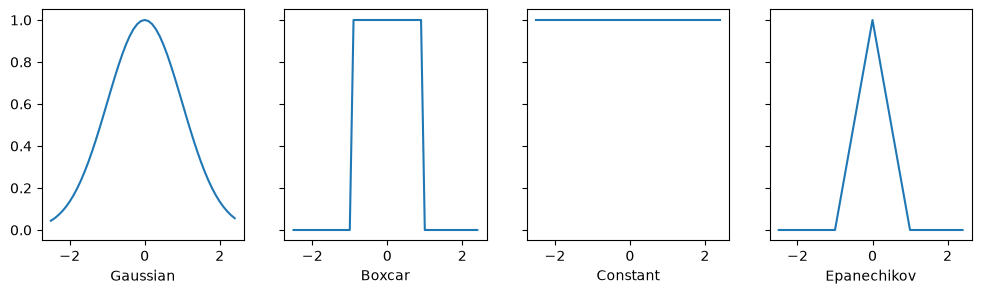

In [6]:
# Kernel Visualization

from asyncio import constants


kernels = (
    gaussian,
    boxcar,
    constant,
    epanechikov,
)

kernel_names = (
    "Gaussian",
    "Boxcar",
    "Constant",
    "Epanechikov",
)

distances = torch.arange(
    -2.5,
    2.5,
    0.1,
)

figure, axes = d2l.plt.subplots(
    1,
    4,
    sharey=True,
    figsize=(12, 3),
)

for kernel, name, axis in zip(
    kernels,
    kernel_names,
    axes,
    strict=True,
):
    similarities = kernel(
        distances
    )

    axis.plot(
        distances.detach().cpu().numpy(),
        similarities.detach().cpu().numpy(),
    )

    axis.set_xlabel(
        name
    )


d2l.plt.show()

In [ ]:
# Regression Data

# Ground Truth Function: y = 2sin(x) + x
def target_function(
    x: torch.Tensor,
) -> torch.Tensor:
    return (
        2 * torch.sin(x)
        + x
    )

num_train = 40
    
# x_train:[40]
x_train, _ = torch.sort(
    torch.rand(num_train) * 5
)

# y_train:[40]
y_train = (
    target_function(x_train)
    + torch.randn(num_train)
)

# x_val:[50]
x_val = torch.arange(
    0,
    5,
    0.1,
)

# y_val:[50]
y_val = target_function(
    x_val
)


print(
    "x_train shape:",
    tuple(x_train.shape),
)
print(
    "y_train shape:",
    tuple(y_train.shape),
)
print(
    "x_val shape:",
    tuple(x_val.shape),
)
print(
    "y_val shape:",
    tuple(y_val.shape),
)


print(
    "\nFirst five training pairs:"
)

for x_value, y_value in zip(
    x_train[:5],
    y_train[:5],
    strict=True,
):
    print(
        f"x={x_value.item():.3f}, "
        f"y={y_value.item():.3f}"
    )

x_train shape: (40,)
y_train shape: (40,)
x_val shape: (50,)
y_val shape: (50,)

First five training pairs:
x=0.024, y=-1.500
x=0.224, y=1.302
x=0.380, y=1.040
x=0.405, y=-0.176
x=0.445, y=1.966
